In [13]:
# Standard library
from pathlib import Path
import sys

# Make the src package importable
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Third-party libraries
import pandas as pd
from sqlalchemy import text
from sqlalchemy.types import Integer, NVARCHAR, DECIMAL

# Local package
from src.database import get_engine

# Create database connection
engine = get_engine()

print("✅ Connected successfully!")

✅ Connected successfully!


In [8]:
# Force Pandas to display floating-point numbers normally instead of in scientific notation
pd.options.display.float_format = '{:.2f}'.format

In [9]:
# 1. Extract Data from Silver Layer
print("Reading data from Silver Layer...")
df_internet = pd.read_sql(
    "SELECT ProductKey, OrderQuantity, SalesAmount, TotalProductCost FROM silver.FactInternetSales",
    con=engine
)
df_reseller = pd.read_sql(
    "SELECT ProductKey, OrderQuantity, SalesAmount, TotalProductCost FROM silver.FactResellerSales",
    con=engine
)
df_products = pd.read_sql(
    "SELECT ProductKey, EnglishProductName FROM silver.DimProduct",
    con=engine
)

# 2. Transform: Combine Sales Channels & Aggregate
print("Unifying internet  and reseller sales channels...")

# Add channel Identifier column to keep track of sources
df_internet['Channel'] = 'Internet'
df_reseller['Channel'] = 'Reseller'

# Concatenate (stack) both tables together
df_all_sales = pd.concat([df_internet,df_reseller],ignore_index=True)

print("Aggregating metrics per product...")
# Group by Productkey to sum up physical and financial metrics
product_metrics = df_all_sales.groupby('ProductKey').agg(
    TotalUnitSold=('OrderQuantity', 'sum'),
    TotalRevenue=('SalesAmount','sum'),
    TotalCost=('TotalProductCost','sum')
).reset_index()

# 3. Merge with Product Details
gold_product_perf = pd.merge(df_products, product_metrics, on="ProductKey", how='inner')

# 4. Compute Profit and Margin Metrics
print("Calculating profit and margin metrics...")
gold_product_perf['TotalProfit'] = gold_product_perf['TotalRevenue'] - gold_product_perf['TotalCost']

# Prevent division-by-zero errors when calculating margins
gold_product_perf['ProfitMargin'] = (
    gold_product_perf['TotalProfit'] / gold_product_perf['TotalRevenue']
).fillna(0)

# Display a preview of your new Gold asset
gold_product_perf.head()


Reading data from Silver Layer...
Unifying internet  and reseller sales channels...
Aggregating metrics per product...
Calculating profit and margin metrics...


,ProductKey,EnglishProductName,TotalUnitSold,TotalRevenue,TotalCost,TotalProfit,ProfitMargin
0,356,"Mountain-200 Silver, 46",1112,1528008.39,1243055.76,284952.63,0.19
1,357,"Mountain-200 Silver, 46",1104,1906248.56,1397243.93,509004.63,0.27
2,348,"Mountain-100 Black, 38",660,1295447.40,1252742.30,42705.09,0.03
3,349,"Mountain-100 Black, 42",618,1222322.82,1173022.34,49300.48,0.04
4,350,"Mountain-100 Black, 44",655,1319277.52,1243251.83,76025.69,0.06


In [12]:
print("Writing processed data gold.FactProductPerformance...")

# Define clean data types for our analytical database table
product_perf_dtypes = {
    'ProductKey': Integer(),
    'EnglishProductName': NVARCHAR(100),
    'TotalUnitsSold':Integer(),
    'TotalRevenue':DECIMAL(18,2),
    'TotalCost':DECIMAL(18,2),
    'TotalProfit':DECIMAL(18,2),
    'ProfitMargin':DECIMAL(5,2) # Stores margin as a decimal fraction (e.g. 0.4550)
}

gold_product_perf.to_sql(
    name='FactProductPerformance', 
    con=engine, 
    schema='gold', 
    if_exists='replace',  # Overwrites the table with fresh calculations
    index=False,
    dtype=product_perf_dtypes
)

print("🎉 gold.FactProductPerformance successfully loaded!")

Writing processed data gold.FactProductPerformance...
🎉 gold.FactProductPerformance successfully loaded!


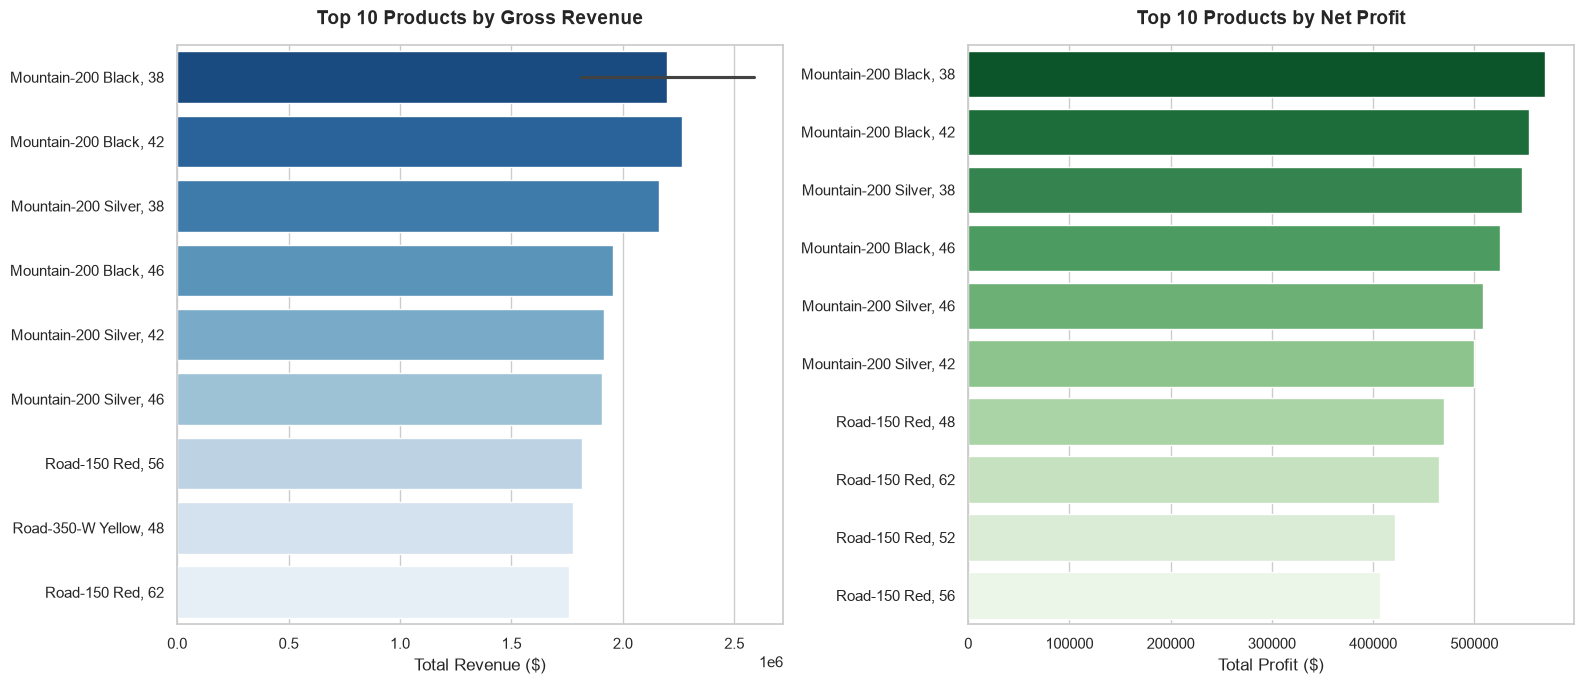

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean style and chart canvas size
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [16, 7]

# Create a 1-row, 2-column plot grid
fig, axes = plt.subplots(1, 2)

# Get top 10 products by Revenue for visualization
top_revenue = gold_product_perf.sort_values(by='TotalRevenue', ascending=False).head(10)

# Get top 10 products by Profit for visualization
top_profit = gold_product_perf.sort_values(by='TotalProfit', ascending=False).head(10)

# --- CHART 1: Top 10 Products by Revenue ---
sns.barplot(
    data=top_revenue,
    x='TotalRevenue',
    y='EnglishProductName',
    ax=axes[0],
    palette='Blues_r',
    hue='EnglishProductName',
    legend=False
)
axes[0].set_title('Top 10 Products by Gross Revenue', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Total Revenue ($)', fontsize=12)
axes[0].set_ylabel('', fontsize=12)

# --- CHART 2: Top 10 Products by Profit ---
sns.barplot(
    data=top_profit,
    x='TotalProfit',
    y='EnglishProductName',
    ax=axes[1],
    palette='Greens_r',
    hue='EnglishProductName',
    legend=False
)
axes[1].set_title('Top 10 Products by Net Profit', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Total Profit ($)', fontsize=12)
axes[1].set_ylabel('', fontsize=12)

# Formatting adjustments
plt.tight_layout()
plt.show()